# Imports

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Data

## Generator

In [119]:

pGa_CONST = {
    'gpt-4o': 0.93478,
    'gpt-4-turbo': 0.872,
    'claude_3_opus': 0.95402,
    'gemini-1.5-pro': 0.92846,
    'deepseek-chat': 0.92841,
    'qwen-coder-plus': 0.93117
}

df_pg = pd.DataFrame(pGa_CONST.items(), columns=['generator', 'precision'])
df_pg['precision'] = df_pg['precision'] * 100
df_pg['validator'] = 'human'
df = df_pg.copy()

df

,generator,precision,validator
0,gpt-4o,93.478,human
1,gpt-4-turbo,87.200,human
2,claude_3_opus,95.402,human
3,gemini-1.5-pro,92.846,human
4,deepseek-chat,92.841,human
5,qwen-coder-plus,93.117,human


## Validator

In [120]:
MODEL_QWEN = 'qwen-coder-plus'
MODEL_DEEPSEEK = 'deepseek-chat'

MODELS = ['gpt-4-turbo', 'gpt-4o-mini', 'gpt-4o', 'claude_3_opus', 'claude_3.5_sonnet', 'gemini-1.5-flash', 'gemini-1.5-pro', MODEL_QWEN, MODEL_DEEPSEEK, 
          'claude_3.5_haiku', 'gemini-2.5-flash-preview-04-17', 'gemini-2.5-pro-preview-03-25', 'gpt-4.1-2025-04-14', 'gpt-4.1-mini-2025-04-14']

MODELS_SHORT = {
    'gpt-4-turbo': 'GPT 4T',
    'gpt-4o-mini': 'GPT 4o-M',
    'gpt-4o': 'GPT 4o',
    'claude_3_opus': 'Opus 3',
    'claude_3.5_sonnet': 'Sonnet 3.5',
    'gemini-1.5-flash': 'G 1.5 flash',
    'gemini-1.5-pro': 'G 1.5 pro',
    MODEL_QWEN: 'Qwen-2.5 Coder',
    MODEL_DEEPSEEK: 'DeepSeek V2.5',
    'claude_3.5_haiku': 'Haiku 3.5',
    'gemini-2.5-flash-preview-04-17': 'G 2.5 flash',
    'gemini-2.5-pro-preview-03-25': 'G 2.5 pro',
    'gpt-4.1-2025-04-14': 'GPT 4.1',
    'gpt-4.1-mini-2025-04-14': 'GPT 4.1-M'
}

PVVA_CONST = np.array([0.9666966667, 0.960885, 0.9649833333, 0.962975, 0.9651233333, 0.97538, 0.960595, 0.948735, 0.97915, 0.9716366667, 0.9130316667, 0.8338383333, 0.96908, 0.9812433333])
PVIVA_CONST = np.array([0.1960216667, 0.2427666667, 0.212795, 0.179535, 0.1954833333, 0.0918116667, 0.1916566667, 0.235205, 0.1588316667, 0.1394433333, 0.4082616667, 0.5225683333, 0.2007916667, 0.1631583333])

pValid = {}
pInvalid = {}

for model, pV in zip(MODELS, PVVA_CONST):
    pValid[model] = pV

for model, pV in zip(MODELS, PVIVA_CONST):
    pInvalid[model] = pV

df_tpr = pd.DataFrame(pValid.items(), columns=['validator', 'tpr'])
df_tnr = pd.DataFrame(pInvalid.items(), columns=['validator', 'tnr'])

df_tpr['tpr'] = df_tpr['tpr'] * 100
df_tnr['tnr'] = df_tnr['tnr'] * 100


## GV

In [121]:
GV_CONST = np.array([
    [0.920365535248, 0.916237113402, 0.887654320988, 0.906868451688, 0.9224537037039999, 0.953575909661, 0.909523809524, 0.881101376721, 0.9460476787950001, 0.937264742785, 0.855172413793, 0.7803738317760001, 0.932183908046, 0.943833943834],
    [0.945889698231, 0.946502057613, 0.941478439425, 0.921267893661, 0.945696721311, 0.967126193001, 0.939809926082, 0.924664602683, 0.9621289662229999, 0.9533678756480001, 0.850976361768, 0.772204806688, 0.957991803279, 0.9761646803899999],
    [0.9756097560979999, 0.968367346939, 0.9736308316429999, 0.9554865424429999, 0.9637681159420001, 0.978766430738, 0.970267591675, 0.961077844311, 0.9831849653810001, 0.9645833333330001, 0.9151329243349999, 0.860061287028, 0.97975708502, 0.9896587383659999],
    [0.961436170213, 0.9523809523810001, 0.970449172577, 0.979761904762, 0.9651741293530001, 0.979381443299, 0.955659276546, 0.941724941725, 0.974448315912, 0.979713603819, 0.9114583333330001, 0.831309041835, 0.9509918319720001, 0.977832512315],
    [0.972251867663, 0.96288209607, 0.9681978798590001, 0.958147818344, 0.982342007435, 0.979371316306, 0.9617097061440001, 0.9600709849160001, 0.9793721973089999, 0.971971066908, 0.9363369245840001, 0.867768595041, 0.982363315697, 0.9876543209880001],
    [0.942891859052, 0.96568627451, 0.957696827262, 0.9718640093790001, 0.955451348183, 0.9864532019700001, 0.9673518742439999, 0.9484412470019999, 0.9775943396229999, 0.977941176471, 0.83556638246, 0.7317365269459999, 0.961313012896, 0.978443113772],
    [0.957851239669, 0.949263502455, 0.9567346938779999, 0.967266775777, 0.9674267100980001, 0.976627712855, 0.975486052409, 0.951946975973, 0.968979591837, 0.973451327434, 0.897157190635, 0.836820083682, 0.962479608483, 0.976686094921],
    [0.958787878788, 0.938118811881, 0.955681818182, 0.953356086462, 0.960648148148, 0.965639810427, 0.936998854525, 0.950631458094, 0.9764573991029999, 0.9751773049649999, 0.88679245283, 0.750295857988, 0.948805460751, 0.964705882353],
    [0.955, 0.948643410853, 0.955980861244, 0.9493177387910001, 0.936585365854, 0.974459724951, 0.950980392157, 0.925603864734, 0.968390804598, 0.954591321897, 0.869950738916, 0.7841365461850001, 0.967615309127, 0.973451327434],
    [0.9643605870019999, 0.945606694561, 0.9646821392530001, 0.9495967741939999, 0.960685483871, 0.9760609358000001, 0.963730569948, 0.939175257732, 0.955600403633, 0.971745711403, 0.868257261411, 0.827657378741, 0.958710976838, 0.981837606838],
    [0.973496432212, 0.969543147208, 0.989226248776, 0.9842983316980001, 0.9900497512440001, 0.9899598393569999, 0.978328173375, 0.9683026584869999, 0.987279843444, 0.982436882547, 0.982071713147, 0.961727183513, 0.9961013645219999, 0.99500998004],
    [0.978260869565, 0.981695568401, 0.991840435177, 0.985546522132, 0.992786293959, 0.992380952381, 0.988752556237, 0.978764478764, 0.988181818182, 0.986998916576, 0.990769230769, 0.975023126735, 0.9954669084319999, 0.9990723562150001],
    [0.981060606061, 0.971114167813, 0.9800703399770001, 0.9732558139530001, 0.9834905660379999, 0.987760097919, 0.98022249691, 0.9618226600990001, 0.988304093567, 0.981927710843, 0.9480198019799999, 0.927696078431, 0.988385598142, 0.991421568627],
    [0.9816216216220001, 0.9752530933629999, 0.9855818743560001, 0.9763130793000001, 0.981462409887, 0.981876332623, 0.971830985915, 0.9621052631579999, 0.984615384615, 0.970133882595, 0.922340425532, 0.88241639698, 0.990769230769, 0.998913043478],
])

li = []
for i, model1 in enumerate(MODELS):
    for j, model2 in enumerate(MODELS):
        li.append([model1, model2, GV_CONST[i][j]*100])
df_gv = pd.DataFrame(li, columns=['generator', 'validator', 'precision'])

df = pd.concat([df_pg, df_gv], ignore_index=True)
df

,generator,precision,validator
0,gpt-4o,93.478000,human
1,gpt-4-turbo,87.200000,human
2,claude_3_opus,95.402000,human
3,gemini-1.5-pro,92.846000,human
4,deepseek-chat,92.841000,human
...,...,...,...
197,gpt-4.1-mini-2025-04-14,97.013388,claude_3.5_haiku
198,gpt-4.1-mini-2025-04-14,92.234043,gemini-2.5-flash-preview-04-17
199,gpt-4.1-mini-2025-04-14,88.241640,gemini-2.5-pro-preview-03-25
200,gpt-4.1-mini-2025-04-14,99.076923,gpt-4.1-2025-04-14


## Ensemble

In [122]:
pEnsemble = {
    'gpt-4-turbo': 0.85029,
    'gpt-4o-mini': 0.89827,
    'gpt-4o': 0.95158,
    'claude_3_opus': 0.93793,
    'claude_3.5_sonnet': 0.95083,
    'gemini-1.5-flash': 0.91472,
    'gemini-1.5-pro': 0.93089,
    'qwen-coder-plus': 0.89709,
    'deepseek-chat': 0.90918,
    'claude_3.5_haiku': 0.92315,
    'gemini-2.5-flash-preview-04-17': 0.97985,
    'gemini-2.5-pro-preview-03-25': 0.98850,
    'gpt-4.1-2025-04-14': 0.97106,
    'gpt-4.1-mini-2025-04-14': 0.95846,
}

df_ensemble = pd.DataFrame(pEnsemble.items(), columns=['generator', 'precision'])
df_ensemble['validator'] = 'ensemble'
df_ensemble['precision'] = df_ensemble['precision'] * 100

df = pd.concat([df, df_ensemble], ignore_index=True)
df
df

,generator,precision,validator
0,gpt-4o,93.478,human
1,gpt-4-turbo,87.200,human
2,claude_3_opus,95.402,human
3,gemini-1.5-pro,92.846,human
4,deepseek-chat,92.841,human
...,...,...,...
211,claude_3.5_haiku,92.315,ensemble
212,gemini-2.5-flash-preview-04-17,97.985,ensemble
213,gemini-2.5-pro-preview-03-25,98.850,ensemble
214,gpt-4.1-2025-04-14,97.106,ensemble


## Regression

In [123]:
pG_ensemble = {
    'gpt-3.5-turbo': 0.655,
    'gpt-4-turbo': 0.918,
    'gpt-4o-mini': 0.952,
    'gpt-4o': 0.925,
    'claude_3_opus': 0.971,
    'claude_3.5_sonnet': 0.971,
    'gemini-1.5-flash': 0.975,
    'gemini-1.5-pro': 0.975,
    'qwen-coder-plus': 0.954,
    'deepseek-chat': 0.955
}

pricing = [1.5, 30, 0.6, 10,
           75, 15,
           0.3, 5,
           0.96, 2.19]

# Elo ranking

In [124]:
eloRating = {
    'gpt-4-turbo': 1256,
    'gpt-4o-mini': 1272,
    'gpt-4o': 1365,
    'claude_3_opus': 1247,
    'claude_3.5_sonnet': 1268,
    'gemini-1.5-flash': 1227,
    'gemini-1.5-pro': 1260,
    'qwen-coder-plus': 1217,
    'deepseek-chat': 1178,
    'claude_3.5_haiku': 1237,
    'gemini-2.5-flash-preview-04-17': 1394,
    'gemini-2.5-pro-preview-03-25': 1446,
    'gpt-4.1-2025-04-14': 1366,
    'gpt-4.1-mini-2025-04-14': 1322,
}

df_elo = pd.DataFrame(eloRating.items(), columns=['generator', 'elo'])

## Elo vs precision

In [125]:
df_elo_prec = pd.merge(df_elo, df, on='generator')
df_plot = df_elo_prec[df_elo_prec['validator'] == 'ensemble']

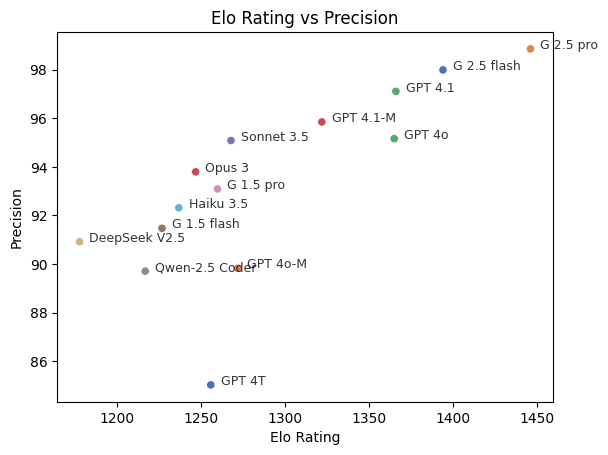

In [126]:
sns.scatterplot(data=df_plot, x='elo', y='precision', hue='generator', palette='deep')
plt.title('Elo Rating vs Precision')
plt.xlabel('Elo Rating')
plt.ylabel('Precision')
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
# Add annotations for each point
for idx, row in df_plot.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])
    plt.annotate(shorthand,  # Use shorthand for model name for clarity
                 xy=(row['elo'], row['precision']),
                 xytext=(7, 0),  # Offset text slightly to the right
                 textcoords='offset points',
                 fontsize=9,
                 alpha=0.8)
    
plt.legend().remove()  # Remove the legend since we have annotations


## Elo vs TPR

In [159]:
df_elo_tpr = pd.merge(df_elo, df_tpr, left_on='generator', right_on='validator')
df_plot = df_elo_tpr

df_plot

,generator,elo,validator,tpr
0,gpt-4-turbo,1256,gpt-4-turbo,96.669667
1,gpt-4o-mini,1272,gpt-4o-mini,96.088500
2,gpt-4o,1365,gpt-4o,96.498333
3,claude_3_opus,1247,claude_3_opus,96.297500
4,claude_3.5_sonnet,1268,claude_3.5_sonnet,96.512333
5,gemini-1.5-flash,1227,gemini-1.5-flash,97.538000
6,gemini-1.5-pro,1260,gemini-1.5-pro,96.059500
7,qwen-coder-plus,1217,qwen-coder-plus,94.873500
8,deepseek-chat,1178,deepseek-chat,97.915000
9,claude_3.5_haiku,1237,claude_3.5_haiku,97.163667


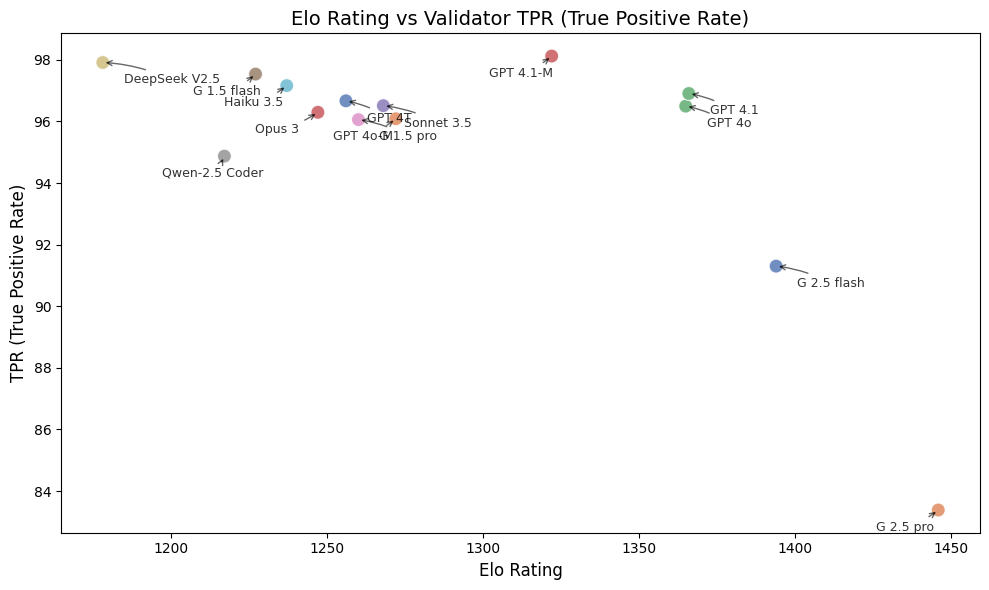

In [161]:
# Create the scatter plot with properly positioned labels
plt.figure(figsize=(10, 6))

# Create the scatterplot without jitter to keep actual data points accurate
sns.scatterplot(
    x='elo', 
    y='tpr', 
    data=df_plot,
    hue='generator', 
    palette='deep',
    s=100,
    alpha=0.8
)

plt.title('Elo Rating vs Validator TPR (True Positive Rate)', fontsize=14)
plt.xlabel('Elo Rating', fontsize=12)
plt.ylabel('TPR (True Positive Rate)', fontsize=12)

# Add annotations with strategic positioning to avoid overlap
for idx, row in df_plot.iterrows():
    shorthand = MODELS_SHORT.get(row['validator'], row['validator'])
    
    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.3:  # Higher TPR models
        y_offset = -15
    else:  # Lower TPR models
        y_offset = 15
    
    # Spread out labels horizontally to reduce overlap
    x_offset = 15 if idx % 2 == 0 else -45
    
    plt.annotate(
        shorthand,
        xy=(row['elo'], row['tpr']),  # Point to exact data point (no jitter)
        xytext=(x_offset, y_offset),  # Offset text for readability
        textcoords='offset points',
        fontsize=9,
        alpha=0.8,
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    )

plt.legend().remove()  # Remove the legend since we have annotations
plt.tight_layout()


## Elo vs TNR

In [127]:
df_elo_tnr = pd.merge(df_elo, df_tnr, left_on='generator', right_on='validator')
df_plot = df_elo_tnr

df_plot

,generator,elo,validator,tnr
0,gpt-4-turbo,1256,gpt-4-turbo,19.602167
1,gpt-4o-mini,1272,gpt-4o-mini,24.276667
2,gpt-4o,1365,gpt-4o,21.279500
3,claude_3_opus,1247,claude_3_opus,17.953500
4,claude_3.5_sonnet,1268,claude_3.5_sonnet,19.548333
5,gemini-1.5-flash,1227,gemini-1.5-flash,9.181167
6,gemini-1.5-pro,1260,gemini-1.5-pro,19.165667
7,qwen-coder-plus,1217,qwen-coder-plus,23.520500
8,deepseek-chat,1178,deepseek-chat,15.883167
9,claude_3.5_haiku,1237,claude_3.5_haiku,13.944333


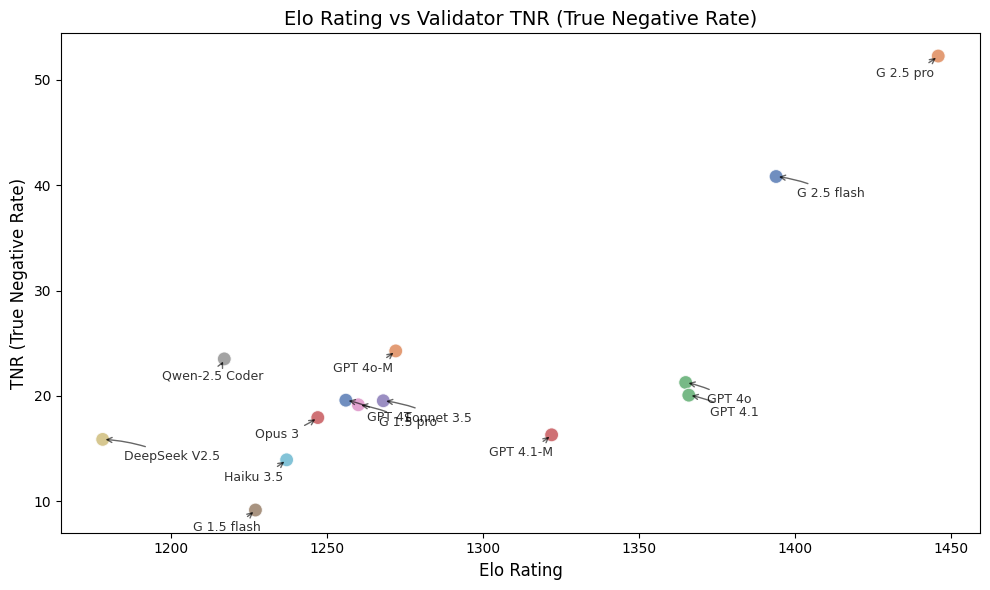

In [128]:
# Create the scatter plot with properly positioned labels
plt.figure(figsize=(10, 6))

# Create the scatterplot without jitter to keep actual data points accurate
sns.scatterplot(
    x='elo', 
    y='tnr', 
    data=df_plot,
    hue='generator', 
    palette='deep',
    s=100,
    alpha=0.8
)

plt.title('Elo Rating vs Validator TNR (True Negative Rate)', fontsize=14)
plt.xlabel('Elo Rating', fontsize=12)
plt.ylabel('TNR (True Negative Rate)', fontsize=12)

# Add annotations with strategic positioning to avoid overlap
for idx, row in df_plot.iterrows():
    shorthand = MODELS_SHORT.get(row['validator'], row['validator'])
    
    # Determine optimal label positioning based on data characteristics
    if row['tnr'] > 0.3:  # Higher TNR models
        y_offset = -15
    else:  # Lower TNR models
        y_offset = 15
    
    # Spread out labels horizontally to reduce overlap
    x_offset = 15 if idx % 2 == 0 else -45
    
    plt.annotate(
        shorthand,
        xy=(row['elo'], row['tnr']),  # Point to exact data point (no jitter)
        xytext=(x_offset, y_offset),  # Offset text for readability
        textcoords='offset points',
        fontsize=9,
        alpha=0.8,
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    )

plt.legend().remove()  # Remove the legend since we have annotations
plt.tight_layout()


# Generator vs Validator

In [129]:
df_gen_valid = pd.merge(df[df['validator'] == 'ensemble'], df_tpr, left_on='generator', right_on='validator')
# Drop existing model_x column to avoid confusion when merging
df_gen_valid.drop(['validator_x'], axis=1, inplace=True)
df_gen_valid.drop(['validator_y'], axis=1, inplace=True)
df_gen_valid = pd.merge(df_gen_valid, df_tnr, left_on='generator', right_on='validator')

df_gen_valid

,generator,precision,tpr,validator,tnr
0,gpt-4-turbo,85.029,96.669667,gpt-4-turbo,19.602167
1,gpt-4o-mini,89.827,96.088500,gpt-4o-mini,24.276667
2,gpt-4o,95.158,96.498333,gpt-4o,21.279500
3,claude_3_opus,93.793,96.297500,claude_3_opus,17.953500
4,claude_3.5_sonnet,95.083,96.512333,claude_3.5_sonnet,19.548333
5,gemini-1.5-flash,91.472,97.538000,gemini-1.5-flash,9.181167
6,gemini-1.5-pro,93.089,96.059500,gemini-1.5-pro,19.165667
7,qwen-coder-plus,89.709,94.873500,qwen-coder-plus,23.520500
8,deepseek-chat,90.918,97.915000,deepseek-chat,15.883167
9,claude_3.5_haiku,92.315,97.163667,claude_3.5_haiku,13.944333


In [ ]:
sns.scatterplot(data=df_gen_valid, x='precision', y='tpr', hue='generator', style='generator', palette='deep')

plt.title('Precision vs True Positive Rate')
plt.xlabel('Precision')
plt.ylabel('True Positive Rate')
# Add annotations for each point
for idx, row in df_gen_valid.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])

    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.5:  # Higher TPR models
        y_offset = -5
    else:  # Lower TPR models
        y_offset = 5

    # Spread out labels horizontally to reduce overlap
    x_offset = 5 if idx % 2 == 0 else -5
    # plt.annotate(
    #     shorthand,
    #     xy=(row['precision'], row['tnr']),  # Point to exact data point (no jitter)
    #     xytext=(x_offset, y_offset),  # Offset text for readability
    #     textcoords='offset points',
    #     fontsize=9,
    #     alpha=0.8,
    #     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    # )
    
    
plt.legend().remove()  # Remove the legend since we have annotations
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

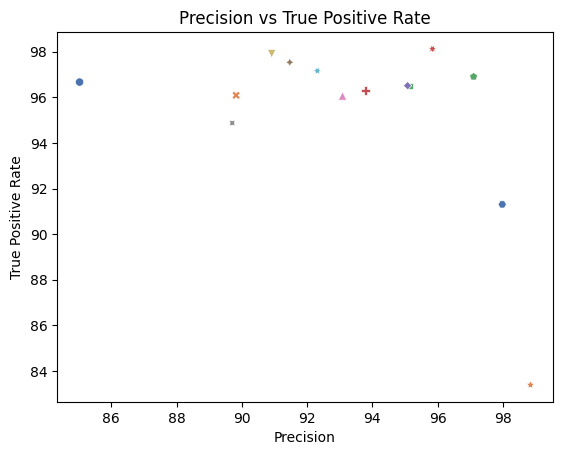

In [157]:
sns.scatterplot(data=df_gen_valid, x='precision', y='tpr', hue='generator', style='generator', palette='deep')

plt.title('Precision vs True Positive Rate')
plt.xlabel('Precision')
plt.ylabel('True Positive Rate')
# Add annotations for each point
for idx, row in df_gen_valid.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])

    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.5:  # Higher TPR models
        y_offset = -5
    else:  # Lower TPR models
        y_offset = 5

    # Spread out labels horizontally to reduce overlap
    x_offset = 5 if idx % 2 == 0 else -5
    # plt.annotate(
    #     shorthand,
    #     xy=(row['precision'], row['tnr']),  # Point to exact data point (no jitter)
    #     xytext=(x_offset, y_offset),  # Offset text for readability
    #     textcoords='offset points',
    #     fontsize=9,
    #     alpha=0.8,
    #     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    # )
    
    
plt.legend().remove()  # Remove the legend since we have annotations
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

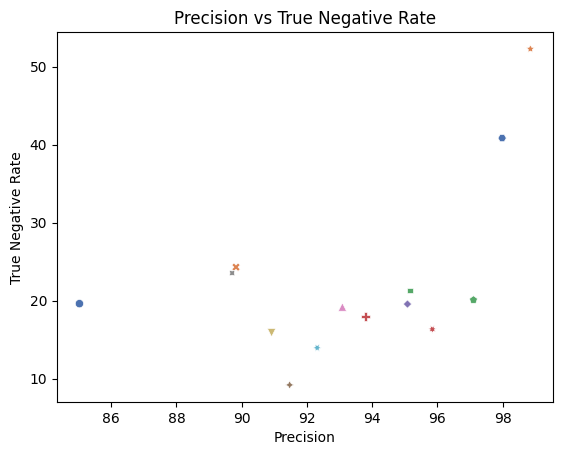

In [156]:
sns.scatterplot(data=df_gen_valid, x='precision', y='tnr', hue='generator', style='generator', palette='deep')

plt.title('Precision vs True Negative Rate')
plt.xlabel('Precision')
plt.ylabel('True Negative Rate')
# Add annotations for each point
for idx, row in df_gen_valid.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])

    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.5:  # Higher TPR models
        y_offset = -5
    else:  # Lower TPR models
        y_offset = 5

    # Spread out labels horizontally to reduce overlap
    x_offset = 5 if idx % 2 == 0 else -5
    # plt.annotate(
    #     shorthand,
    #     xy=(row['precision'], row['tnr']),  # Point to exact data point (no jitter)
    #     xytext=(x_offset, y_offset),  # Offset text for readability
    #     textcoords='offset points',
    #     fontsize=9,
    #     alpha=0.8,
    #     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.6)
    # )
    
    
plt.legend().remove()  # Remove the legend since we have annotations
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

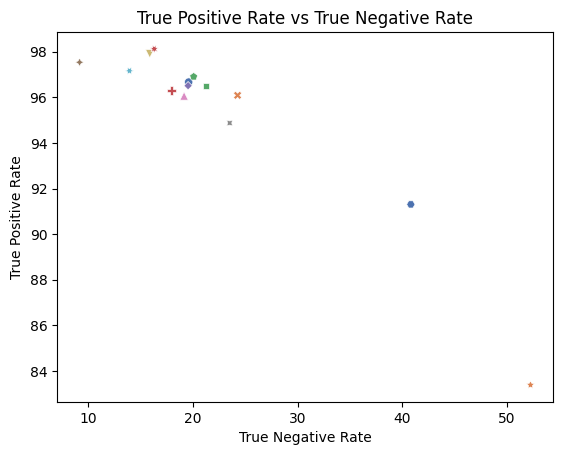

In [152]:
sns.scatterplot(data=df_gen_valid, x='tnr', y='tpr', hue='generator', style='generator', palette='deep')

plt.title('True Positive Rate vs True Negative Rate')
plt.xlabel('True Negative Rate')
plt.ylabel('True Positive Rate')
# Add annotations for each point
for idx, row in df_gen_valid.iterrows():
    shorthand = MODELS_SHORT.get(row['generator'], row['generator'])

    # Determine optimal label positioning based on data characteristics
    if row['tpr'] > 0.5:  # Higher TPR models
        y_offset = -15
    else:  # Lower TPR models
        y_offset = 15
        
    # plt.annotate(shorthand,  # Use shorthand for model name for clarity
    #              xy=(row['tnr'], row['tpr']),
    #              xytext=(7, 0),  # Offset text slightly to the right
    #              textcoords='offset points',
    #              fontsize=9,
    #              alpha=0.8)
    
plt.legend().remove()  # Remove the legend since we have annotations
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

# GV Plot

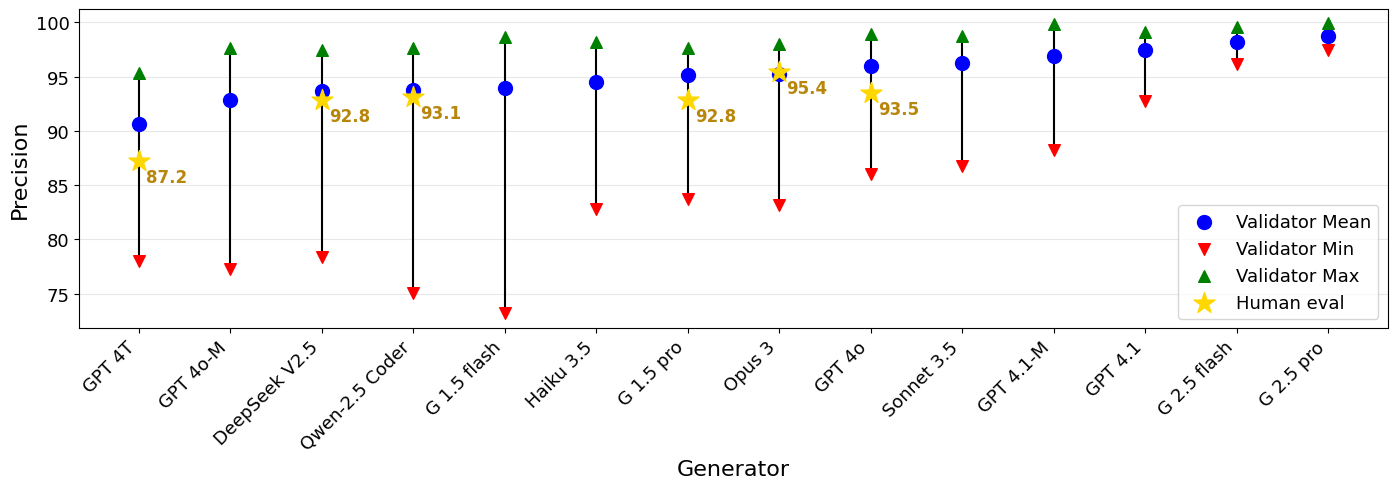

In [ ]:
df_gv

# Create a figure
plt.figure(figsize=(14, 5))

# Group by generator to get statistics for each
grouped = df_gv.groupby('generator')
stats = grouped.agg({'precision': ['mean', 'min', 'max']})
stats.columns = ['mean', 'min', 'max']
stats = stats.reset_index()

# Sort by mean precision for better visualization
stats = stats.sort_values('mean', ascending=True)

# Plot vertical lines from min to max
for i, row in enumerate(stats.itertuples()):
    plt.plot([i, i], [row.min, row.max], 'k-', linewidth=1.5)
    
# Plot mean markers
plt.scatter(range(len(stats)), stats['mean'], color='blue', s=100, zorder=3, label='Validator Mean')
plt.scatter(range(len(stats)), stats['min'], color='red', s=70, zorder=3, marker='v', label='Validator Min')
plt.scatter(range(len(stats)), stats['max'], color='green', s=70, zorder=3, marker='^', label='Validator Max')

# Add a scatter for human ground truth evaluations from df_pg
for i, row in df_pg.iterrows():
    # Find the position in stats dataframe
    gen_idx = stats[stats['generator'] == row['generator']].index
    if len(gen_idx) > 0:
        idx = stats.index.get_loc(gen_idx[0])
        plt.scatter([idx], [row['precision']], color='gold', marker='*', s=250, zorder=4, 
                    label='Human eval' if i == 0 else "")
        
        # Add annotation for the human evaluation with precision multiplied by 100
        plt.annotate(f"{row['precision']:.1f}", 
                     xy=(idx, row['precision']), 
                     xytext=(20, -15),  # Offset below the point
                     textcoords='offset points', 
                     ha='center', 
                     color='darkgoldenrod',
                     fontweight='bold',
                     fontsize=12)

# Set x-tick labels to model names, using shorthand for readability
plt.xticks(range(len(stats)), [MODELS_SHORT.get(model, model) for model in stats['generator']], 
           rotation=45, ha='right', fontsize=13)

plt.ylabel('Precision', fontsize=16)
plt.xlabel('Generator', fontsize=16)
plt.grid(True, axis='y', alpha=0.3)
# plt.title('Generator Precision by Different Validators', fontsize=18, pad=15)
plt.legend(fontsize=13)
plt.tight_layout()

# Increase the size of tick labels
plt.yticks(fontsize=13)

# Save with high DPI for crisp text
plt.savefig('../output/images/pdfs/gv.pdf', bbox_inches='tight')

# Error plots

# Pricing 

In [133]:
# Create the scatter plot with log scale on x-axis
plt.figure(figsize=(10, 6))
plt.scatter(df['pricing'], df['pG'], alpha=0.7, s=100)
# Add labels for each point with offset based on model positions
offsets = {
    'gpt-3.5-turbo': (-20, -15),
    'gpt-4-turbo': (10, 5),
    'gpt-4o-mini': (-40, -5),
    'gpt-4o': (10, 10),
    'claude_3_opus': (10, -10),
    'claude_3.5_sonnet': (-30, 15),
    'gemini-1.5-flash': (-80, -10),
    'gemini-1.5-pro': (10, -15),
    'qwen-coder-plus': (-30, 20),
    'deepseek-chat': (15, 10)
}

for i, model in enumerate(df['model']):
    plt.annotate(model, 
                (df['pricing'].iloc[i], df['pG'].iloc[i]),
                xytext=offsets[model], 
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', alpha=0.7))

# Add title and labels
plt.title('Generator Precision (ensemble) vs Pricing', fontsize=14)
plt.xlabel('Price per 1M output tokens (log scale)', fontsize=12)
plt.ylabel('Generator Precision', fontsize=12)
plt.grid(True, alpha=0.3)

# Set x-axis to log scale
plt.xscale('log')

# Set x-axis limits from 10^0 to 10^2
plt.xlim(100, 0.1)  # Flipped the order to go from high to low
plt.ylim(0.9, 1.0)

plt.tight_layout()
plt.show()


KeyError: 'pricing'

<Figure size 1000x600 with 0 Axes>

# Loss ablation

## Loss plots

In [ ]:
def plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[], ylim=1e-3):
    weightGV, weightG, weightVV, weightVIV = weights
    weightsStr = '-'.join(map(str, weights))
    df = pd.read_csv(f'../output/logs/loss iteration/{method}_{lossGV}_{lossOthers}_{weightsStr}.csv')
    
    plt.figure(figsize=(12, 6))

    # Get the last values for annotations
    last_iter = df['iter'].iloc[-1]
    last_train_loss_GV = df['train_loss_GV'].iloc[-1]
    last_train_loss_g = df['train_loss_g'].iloc[-1]
    last_train_loss_vv = df['train_loss_vv'].iloc[-1]
    last_train_loss_viv = df['train_loss_viv'].iloc[-1]
    last_test_loss_g = df['test_loss_g'].iloc[-1]

    # Plot all training losses with solid lines
    plt.plot(df['iter'], df['train_loss_GV'], color='green', linewidth=2, label=f'GV ({weightGV}x)')
    plt.plot(df['iter'], df['train_loss_vv'], color='purple', linewidth=2, label=f'V+ ({weightVV}x)')
    plt.plot(df['iter'], df['train_loss_viv'], color='orange', linewidth=2, label=f'V- ({weightVIV}x)')
    plt.plot(df['iter'], df['test_loss_g'], color='red', linewidth=2, linestyle='--', label='G Test')
    plt.plot(df['iter'], df['train_loss_g'], color='blue', linewidth=2, label=f'G Train ({weightG}x)')

    # Add annotations for the final values
    plt.annotate(f'{last_train_loss_GV:.6f}', xy=(last_iter, last_train_loss_GV), 
                 xytext=(last_iter + 50, last_train_loss_GV), color='green')
    
    plt.annotate(f'{last_train_loss_vv:.6f}', xy=(last_iter, last_train_loss_vv), 
                 xytext=(last_iter + 50, last_train_loss_vv), color='purple')
    
    plt.annotate(f'{last_train_loss_viv:.6f}', xy=(last_iter, last_train_loss_viv), 
                 xytext=(last_iter + 50, last_train_loss_viv), color='orange')
    
    plt.annotate(f'{last_test_loss_g:.6f}', xy=(last_iter, last_test_loss_g), 
                 xytext=(last_iter + 50, last_test_loss_g), color='red')
    
    plt.annotate(f'{last_train_loss_g:.6f}', xy=(last_iter, last_train_loss_g), 
                 xytext=(last_iter + 50, last_train_loss_g), color='blue')

    # Add labels and title
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'k={k} method={method} lossGV={lossGV} lossOthers={lossOthers}', fontsize=14)

    # Add grid and legend
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)

    # Use log scale for y-axis as the loss values span several orders of magnitude
    plt.yscale('log')

    # Add some padding to the x-axis to make room for annotations
    plt.xlim(0, last_iter + 350)
    plt.ylim(ylim, 1)

    plt.tight_layout()
    plt.show()

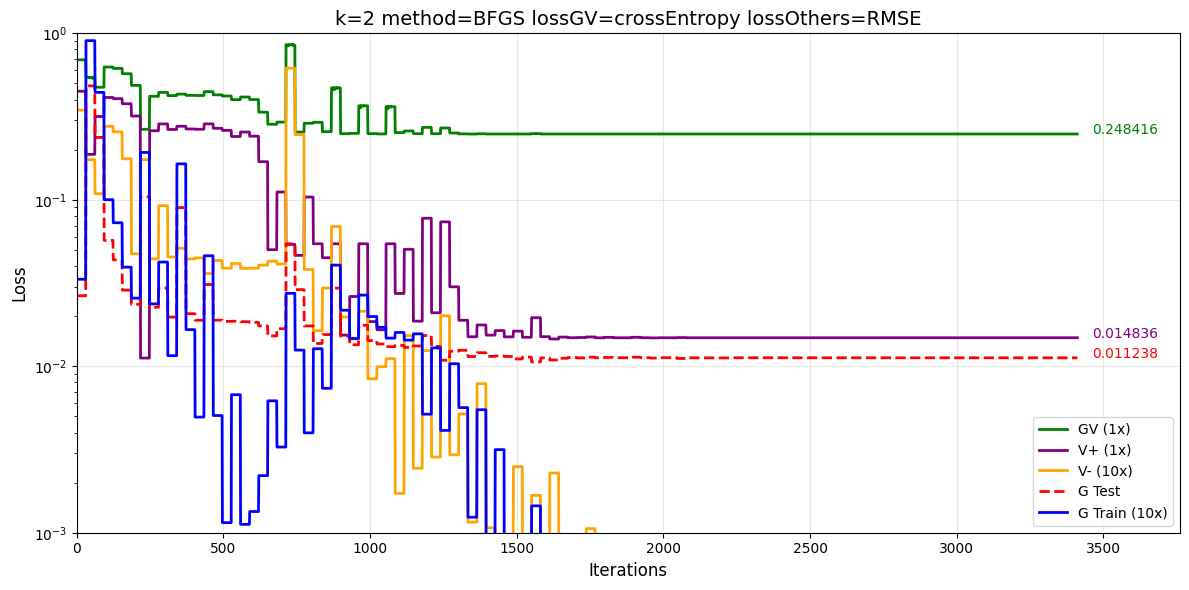

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 10, 1, 10])

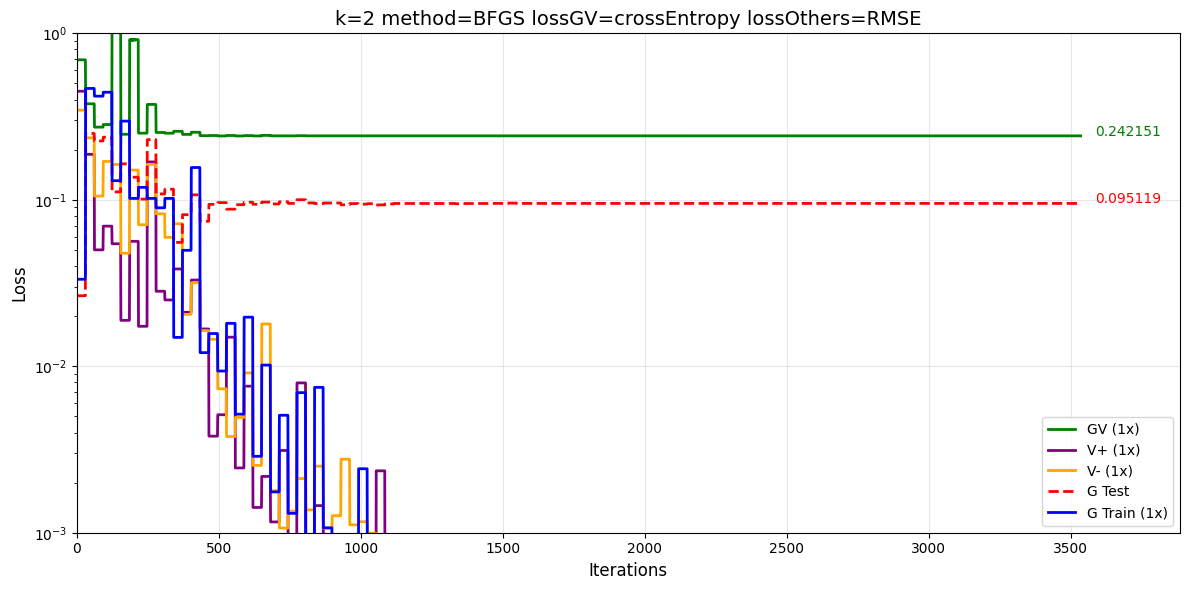

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 1, 1, 1])

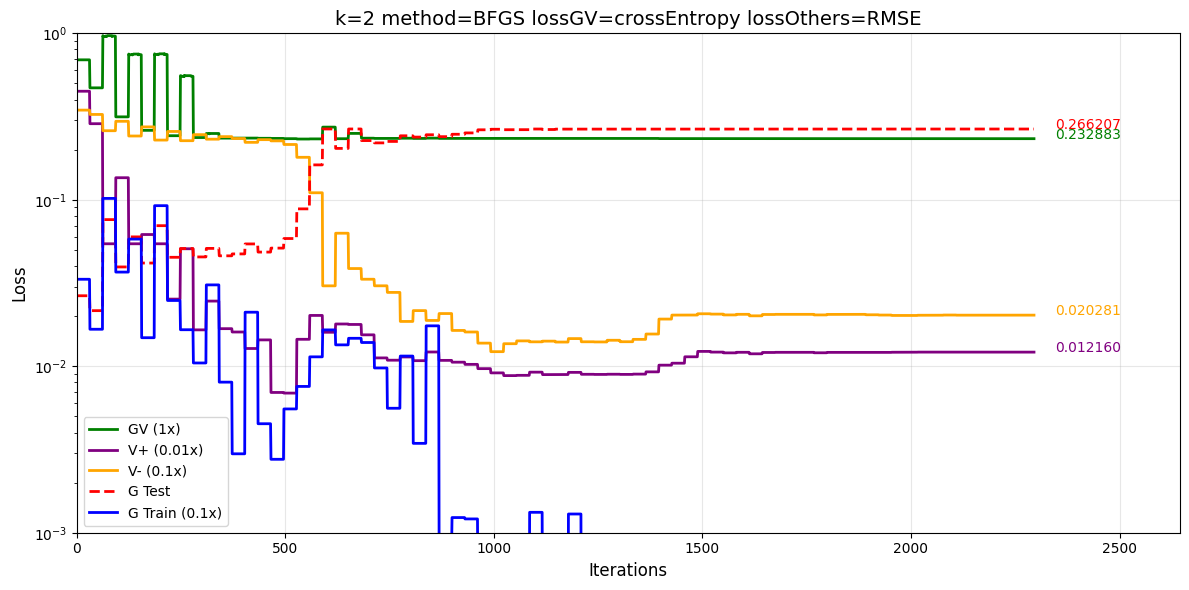

In [ ]:

plot_loss(k=2, method='BFGS', lossGV='crossEntropy', lossOthers='RMSE', weights=[1, 0.1, 0.01, 0.1])

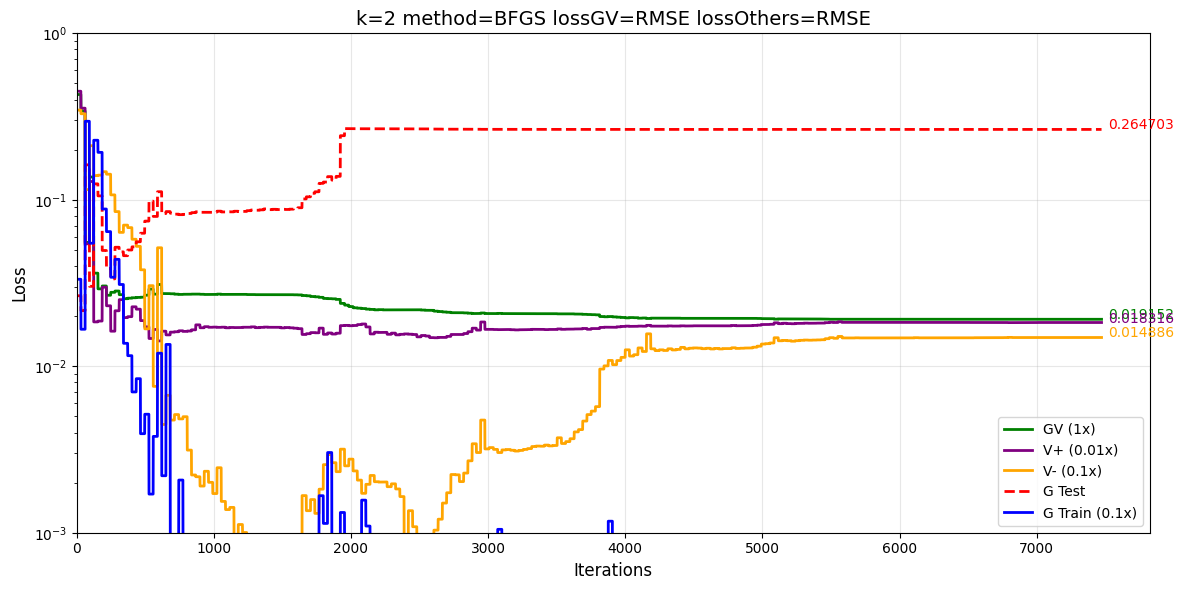

In [ ]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 0.1, 0.01, 0.1])

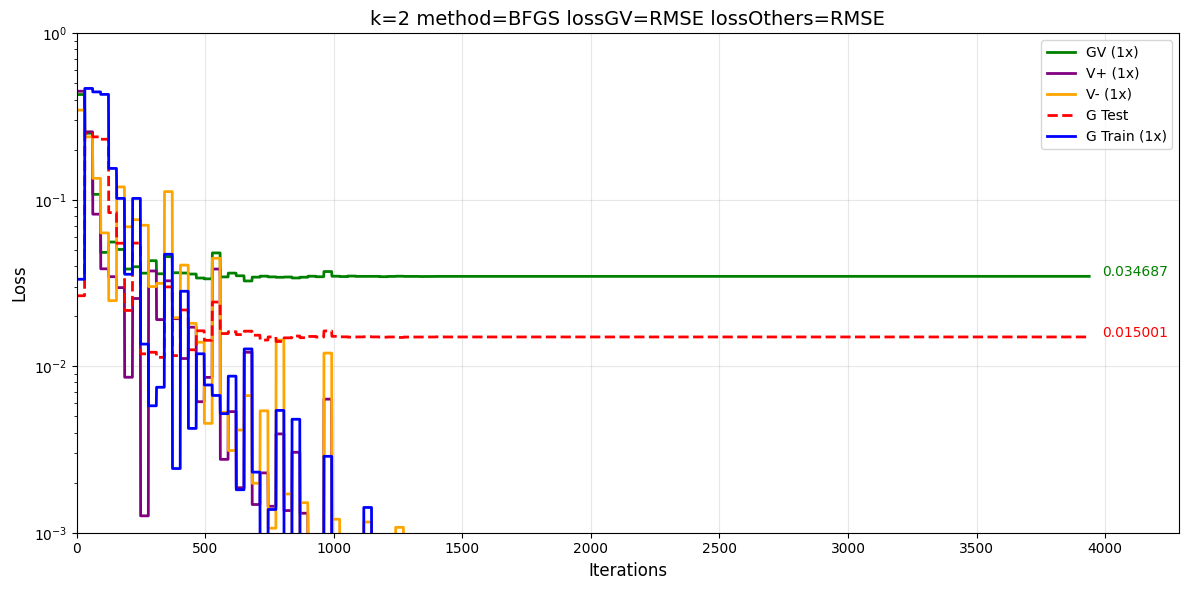

In [ ]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 1, 1, 1])

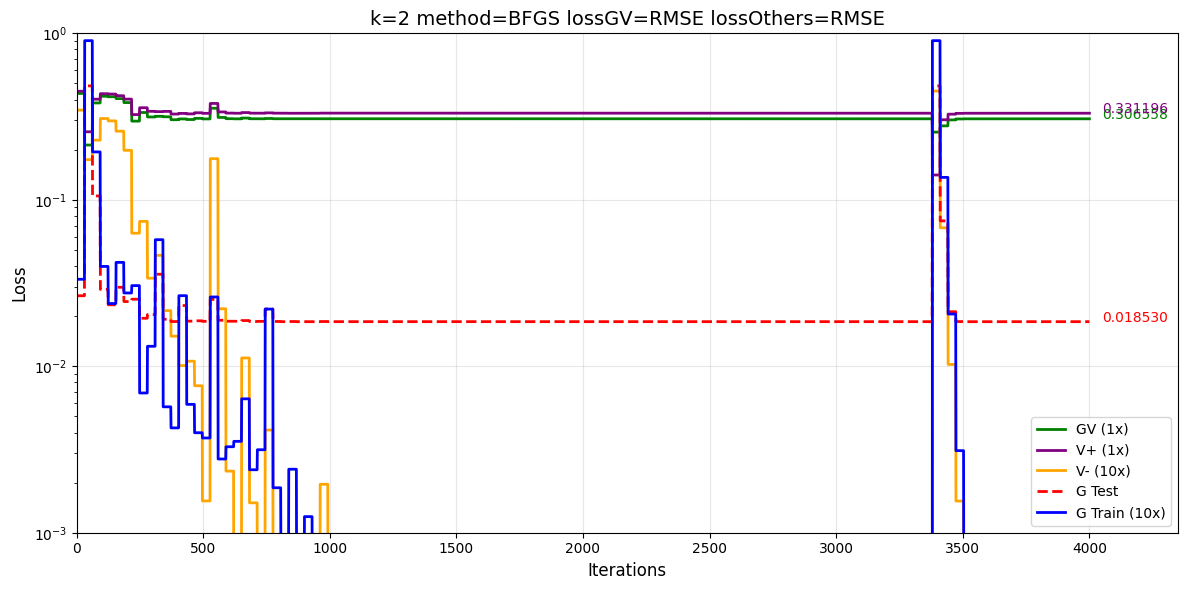

In [ ]:

plot_loss(k=2, method='BFGS', lossGV='RMSE', lossOthers='RMSE', weights=[1, 10, 1, 10])

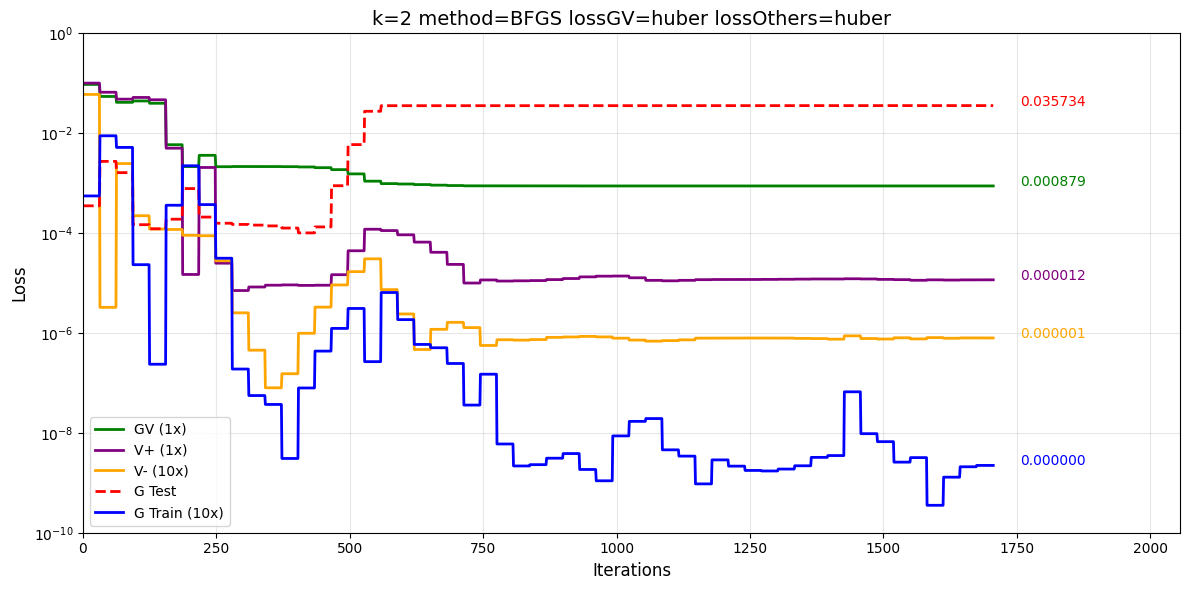

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='huber', lossOthers='huber', weights=[1, 10, 1, 10], ylim=1e-10)

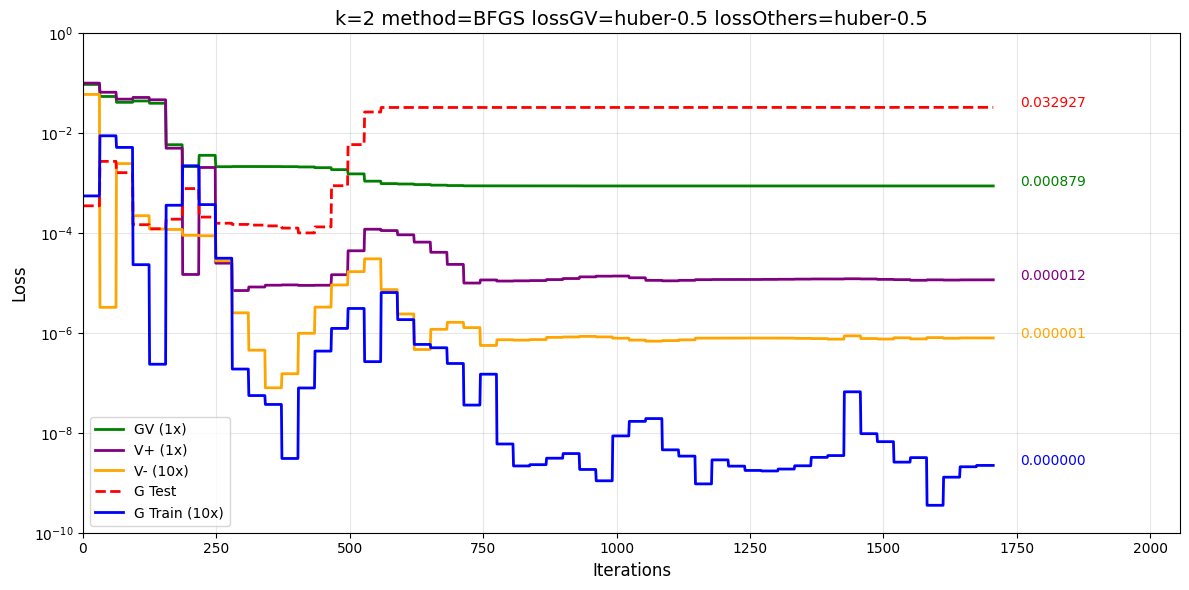

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.5', lossOthers='huber-0.5', weights=[1, 10, 1, 10], ylim=1e-10)

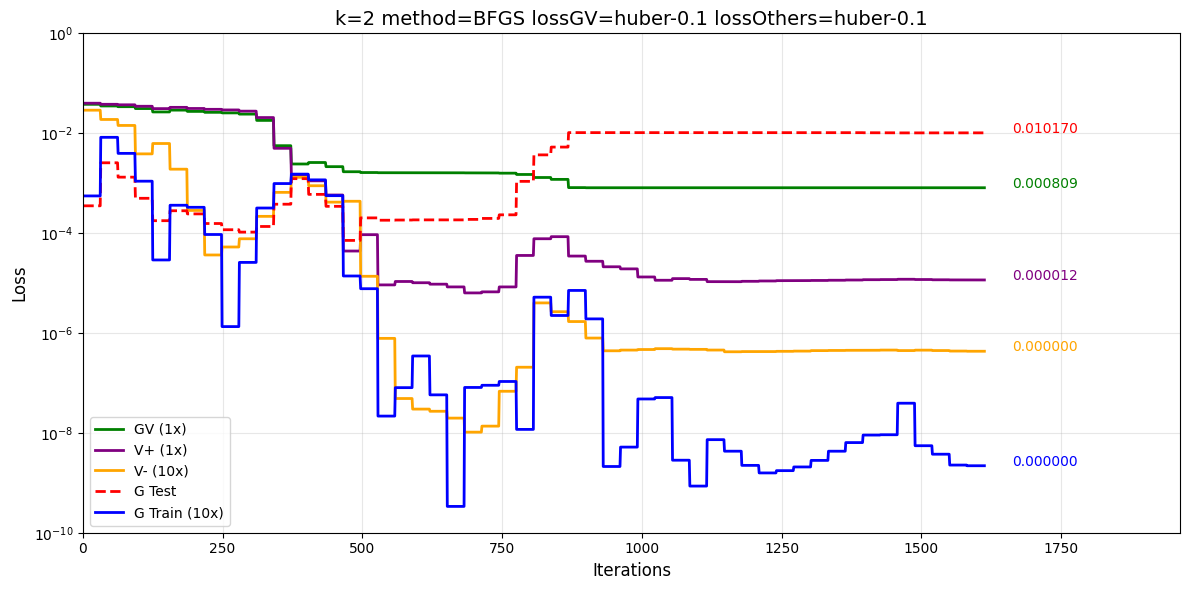

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.1', lossOthers='huber-0.1', weights=[1, 10, 1, 10], ylim=1e-10)

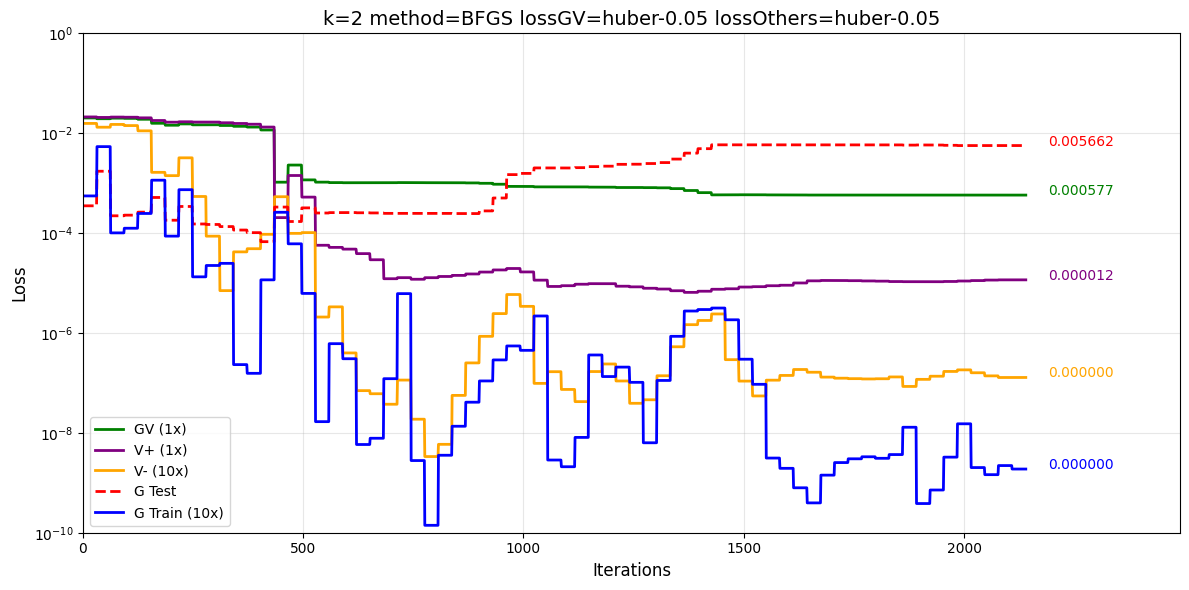

In [ ]:
plot_loss(k=2, method='BFGS', lossGV='huber-0.05', lossOthers='huber-0.05', weights=[1, 10, 1, 10], ylim=1e-10)